# MERIDIAN — Analysis Module 2: Currency-Normalized Revenue Reporting

## Business question
Meridian Commerce's finance, marketing, and operations teams each see a different number when they say "revenue" — because none of them account for refunds, and none of them compare currencies fairly. This notebook answers, once and for all:

- What is our **tracked revenue** (everything sold, before refunds) per region, in comparable USD terms?
- What is our **realized revenue** (what we actually kept, after refunds) per region?
- How much of a difference does that make — and which regions lose the most to refunds?

## Why "tracked" vs "realized" is a real distinction, not just semantics
- **Tracked revenue** = the value of every order placed, regardless of what happened to it afterward. This is what a marketing dashboard usually shows — it looks impressive, but it isn't money in the bank.
- **Realized revenue** = tracked revenue minus anything that was refunded. This is closer to what finance actually books.
Conflating the two is a classic new-analyst mistake — and a classic interview question. This notebook keeps them clearly separate.

## Step 1 — Connect to SQL Server

This reuses the same driver-detection approach from the Phase 2 loader script (preferring the modern ODBC driver over the legacy one — see PROJECT_LOG.md for why that matters).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
print("Connected.")

Connected.


## Step 2 — Pull the unified orders data

Straight from `marts.fct_orders` — the single source of truth built in Phase 3. No cleaning needed here; that work is already done.

In [2]:
orders = pd.read_sql("SELECT * FROM marts.fct_orders", engine)
print(f"{len(orders):,} total orders loaded across all regions")
orders.head()

159,120 total orders loaded across all regions


,order_id,customer_id,region,currency_code,amount_local,amount_usd,product_category,order_date,delivered_date,is_refunded,refund_date,review_score,order_status,source_system
0,US-ORD-000000,US-CUST-00392,US,USD,97.35,97.35,Electronics,2023-11-24,2023-11-28 00:00:00,True,2023-12-11,4.0,completed,synthetic
1,US-ORD-000001,US-CUST-00255,US,USD,143.54,143.54,Books,2025-07-10,2025-07-14 12:45:00,False,NaT,3.0,completed,synthetic
2,US-ORD-000002,US-CUST-00292,US,USD,146.06,146.06,Grocery,2024-01-17,2024-01-23 12:50:12,False,NaT,3.0,completed,synthetic
3,US-ORD-000003,US-CUST-00327,US,USD,99.42,99.42,Fashion,2023-10-05,2023-10-09 00:00:00,False,NaT,NaN,completed,synthetic
4,US-ORD-000004,US-CUST-00205,US,USD,54.04,54.04,Sports,2024-08-17,2024-08-22 11:36:00,False,NaT,2.0,completed,synthetic


## Step 3 — Tracked vs. realized revenue, by region

- **Tracked** = the gross value of genuine sales (`amount_usd > 0`), regardless of what happened after.
- **Realized** = tracked minus the actual refund impact.

**A real bug was caught and fixed here, worth keeping in the write-up:** the first version of this calculation summed `amount_usd` for "tracked" and only non-refunded rows for "realized" - which works for US/DE/GH/Olist (a refunded order there keeps its original *positive* value, just flagged), but silently breaks for UCI (UK) data, where a cancellation is stored as its own *separate, negative-valued* row rather than a flag on the original order. That mismatch made UK's "realized" revenue come out *higher* than "tracked" - impossible in reality. The fix below explicitly separates "value of genuine sales" from "refund impact" (using absolute value), which produces correct results under both data conventions at once.

In [3]:
# Tracked = value of genuine sales only (ignores pure-return rows, which
# have amount_usd <= 0 in sources like UCI where a cancellation is its
# own negative-valued row rather than a flag on the original order)
orders['sale_value'] = orders['amount_usd'].where(orders['amount_usd'] > 0, 0)
tracked = orders.groupby('region')['sale_value'].sum().rename('tracked_revenue_usd')

# Refund impact = absolute value of whatever was refunded, regardless of
# whether the source records it as a flagged positive order (US/DE/GH/Olist)
# or a separate negative row (UCI)
orders['refund_impact'] = orders['amount_usd'].abs().where(orders['is_refunded'] == 1, 0)
refund_impact = orders.groupby('region')['refund_impact'].sum().rename('revenue_lost_to_refunds_usd')

realized = (tracked - refund_impact).rename('realized_revenue_usd')
refund_rate = orders.groupby('region')['is_refunded'].mean().rename('refund_rate')

revenue_summary = pd.concat([tracked, realized, refund_rate, refund_impact], axis=1)
revenue_summary = revenue_summary.sort_values('tracked_revenue_usd', ascending=False)
revenue_summary.round(2)

,tracked_revenue_usd,realized_revenue_usd,refund_rate,revenue_lost_to_refunds_usd
region,,,,
UK,28614654.77,26530712.59,0.15,2083942.18
BR,3064153.16,3043674.80,0.01,20478.36
DE,154538.53,139915.45,0.09,14623.08
US,153585.22,143984.13,0.07,9601.09
GH,53206.47,50265.52,0.05,2940.95


## Step 4 — Visualize it

A side-by-side bar chart makes the tracked-vs-realized gap immediately obvious, region by region — this is the kind of chart that goes straight into a case study or a Power BI dashboard later.

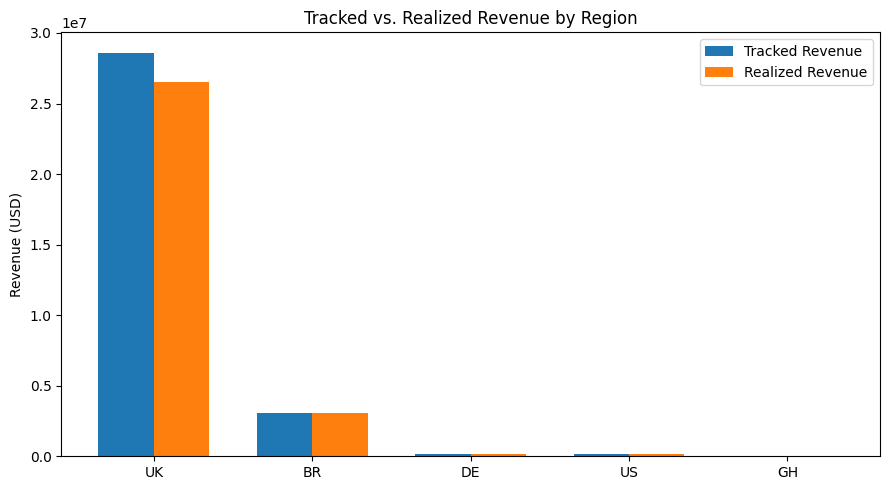

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(revenue_summary))
width = 0.35

ax.bar([i - width/2 for i in x], revenue_summary['tracked_revenue_usd'], width, label='Tracked Revenue')
ax.bar([i + width/2 for i in x], revenue_summary['realized_revenue_usd'], width, label='Realized Revenue')

ax.set_xticks(list(x))
ax.set_xticklabels(revenue_summary.index)
ax.set_ylabel('Revenue (USD)')
ax.set_title('Tracked vs. Realized Revenue by Region')
ax.legend()
plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=120)
plt.show()

## Step 5 — Refund rate by region

Which regions lose the highest *share* of their revenue to refunds — not just the highest dollar amount?

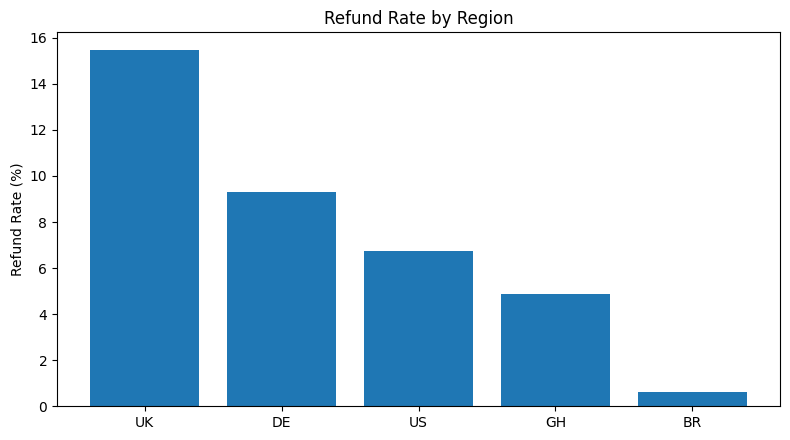

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
refund_sorted = revenue_summary['refund_rate'].sort_values(ascending=False)
ax.bar(refund_sorted.index, refund_sorted.values * 100)
ax.set_ylabel('Refund Rate (%)')
ax.set_title('Refund Rate by Region')
plt.tight_layout()
plt.savefig('refund_rate_by_region.png', dpi=120)
plt.show()

## Findings
Our UK region drove the most revenue (~$28.6M) but also lost the most to refunds (15%, ~$2.08M) — more than every other region combined. Brazil, our second-largest market, was proportionally our cleanest at just 1% refunds.